# XGBoost Forecasting

This notebook evaluates XGBoost as a feature-based demand forecasting model for the `FOODS`, `HOBBIES`, and `HOUSEHOLD` categories.

It uses the same 13 expanding monthly validation windows as the baseline, Linear Regression, and Prophet notebooks. Lag, rolling-average, calendar, time-trend, and Christmas features are used to predict future demand recursively.

Main objectives:

1. Fit an initial XGBoost model and review one validation forecast.
2. Test a small number of understandable XGBoost configurations.
3. Select the best configuration per category using validation WAPE and stability.
4. Review feature importance.
5. Compare XGBoost with ETS, Linear Regression, and Prophet.
6. Refit and save the selected XGBoost setup using all pre-test data.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor

import models_metrics


In [2]:
train_data = pd.read_parquet(
    "data/processed/train_data.parquet"
)

validation_data = pd.read_parquet(
    "data/processed/validation_data.parquet"
)

validation_windows = pd.read_parquet(
    "data/processed/validation_windows.parquet"
)


In [3]:
development_data = pd.concat(
    [train_data, validation_data],
    ignore_index=True,
)

development_daily = (
    development_data
    .groupby(
        ["cat_id", "ds"],
        observed=True,
        as_index=False,
    )
    .agg(y=("y", "sum"))
    .sort_values(["cat_id", "ds"])
    .reset_index(drop=True)
)

development_daily


,cat_id,ds,y
0,HOBBIES,2011-01-29,3764.0
1,HOBBIES,2011-01-30,3357.0
2,HOBBIES,2011-01-31,2682.0
3,HOBBIES,2011-02-01,2669.0
4,HOBBIES,2011-02-02,1814.0
...,...,...,...
4807,FOODS,2015-06-16,21346.0
4808,FOODS,2015-06-17,20254.0
4809,FOODS,2015-06-18,22419.0
4810,FOODS,2015-06-19,24540.0


In [4]:
featured_data = development_daily.copy()

for lag in [1, 7, 14, 28]:
    featured_data[f"lag_{lag}"] = (
        featured_data
        .groupby("cat_id")["y"]
        .shift(lag)
    )

featured_data["rolling_mean_7"] = (
    featured_data
    .groupby("cat_id")["y"]
    .transform(
        lambda series: series.shift(1).rolling(7).mean()
    )
)

featured_data["rolling_mean_28"] = (
    featured_data
    .groupby("cat_id")["y"]
    .transform(
        lambda series: series.shift(1).rolling(28).mean()
    )
)

featured_data["day_of_week"] = (
    featured_data["ds"].dt.dayofweek
)

featured_data["month"] = featured_data["ds"].dt.month

featured_data["time_index"] = (
    featured_data
    .groupby("cat_id")
    .cumcount()
)

featured_data["is_christmas"] = (
    (featured_data["ds"].dt.month == 12)
    & (featured_data["ds"].dt.day == 25)
).astype(int)

model_data = pd.get_dummies(
    featured_data,
    columns=["day_of_week", "month"],
    drop_first=True,
    dtype=int,
)

model_data


/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_17063/3557754489.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cat_id")["y"]
/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_17063/3557754489.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("cat_id")["y"]
/var/folders/g4/9g6d0hm90nz01b5h5psjc6s80000gn/T/ipykernel_17063/3557754489.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this war

,cat_id,ds,y,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,time_index,...,month_3,month_4,month_5,month_6,month_7,month_8,month_9,month_10,month_11,month_12
0,HOBBIES,2011-01-29,3764.0,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,0
1,HOBBIES,2011-01-30,3357.0,3764.0,NaN,NaN,NaN,NaN,NaN,1,...,0,0,0,0,0,0,0,0,0,0
2,HOBBIES,2011-01-31,2682.0,3357.0,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,0
3,HOBBIES,2011-02-01,2669.0,2682.0,NaN,NaN,NaN,NaN,NaN,3,...,0,0,0,0,0,0,0,0,0,0
4,HOBBIES,2011-02-02,1814.0,2669.0,NaN,NaN,NaN,NaN,NaN,4,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4807,FOODS,2015-06-16,21346.0,34524.0,26624.0,24951.0,19435.0,28488.285714,24861.857143,1599,...,0,0,0,1,0,0,0,0,0,0
4808,FOODS,2015-06-17,20254.0,21346.0,23633.0,24806.0,19514.0,27734.285714,24930.107143,1600,...,0,0,0,1,0,0,0,0,0,0
4809,FOODS,2015-06-18,22419.0,20254.0,24558.0,22797.0,19400.0,27251.571429,24956.535714,1601,...,0,0,0,1,0,0,0,0,0,0
4810,FOODS,2015-06-19,24540.0,22419.0,27193.0,26735.0,22834.0,26946.000000,25064.357143,1602,...,0,0,0,1,0,0,0,0,0,0


In [5]:
base_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "time_index",
    "is_christmas",
]

calendar_features = [
    column
    for column in model_data.columns
    if column.startswith("day_of_week_")
    or column.startswith("month_")
]

feature_columns = base_features + calendar_features

len(feature_columns)


25

## Initial XGBoost Forecast

Before running the full validation process, this section fits one model for `FOODS` and forecasts the first validation window. XGBoost does not need feature scaling.


In [6]:
category = "FOODS"

window = validation_windows.iloc[0]

train = development_daily[
    (development_daily["cat_id"] == category)
    & (development_daily["ds"] <= window["train_end"])
].copy()

validation = development_daily[
    (development_daily["cat_id"] == category)
    & (development_daily["ds"] >= window["validation_start"])
    & (development_daily["ds"] <= window["validation_end"])
].copy()

train_model_data = model_data[
    (model_data["cat_id"] == category)
    & (model_data["ds"] <= window["train_end"])
].dropna(subset=base_features)

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    random_state=42,
    objective="reg:squarederror",
)

xgb_model.fit(
    train_model_data[feature_columns],
    train_model_data["y"],
)

history = train["y"].astype(float).tolist()
forecasts = []

for forecast_date in validation["ds"]:

    forecast_features = pd.DataFrame(
        {
            "lag_1": [history[-1]],
            "lag_7": [history[-7]],
            "lag_14": [history[-14]],
            "lag_28": [history[-28]],
            "rolling_mean_7": [sum(history[-7:]) / 7],
            "rolling_mean_28": [sum(history[-28:]) / 28],
            "time_index": [len(history)],
            "is_christmas": [
                int(
                    forecast_date.month == 12
                    and forecast_date.day == 25
                )
            ],
            "day_of_week": [forecast_date.dayofweek],
            "month": [forecast_date.month],
        }
    )

    forecast_features = pd.get_dummies(
        forecast_features,
        columns=["day_of_week", "month"],
        dtype=int,
    )

    forecast_features = forecast_features.reindex(
        columns=feature_columns,
        fill_value=0,
    )

    prediction = xgb_model.predict(
        forecast_features
    )[0]

    prediction = max(0, prediction)

    forecasts.append(prediction)
    history.append(prediction)

first_xgb_metrics = (
    models_metrics.calculate_validation_metrics(
        actual=validation["y"],
        forecast=forecasts,
    )
)

first_xgb_metrics


{'MAE': np.float64(1096.830859375),
 'RMSE': np.float64(1410.3847994410442),
 'WAPE (%)': np.float64(4.565201966939844)}

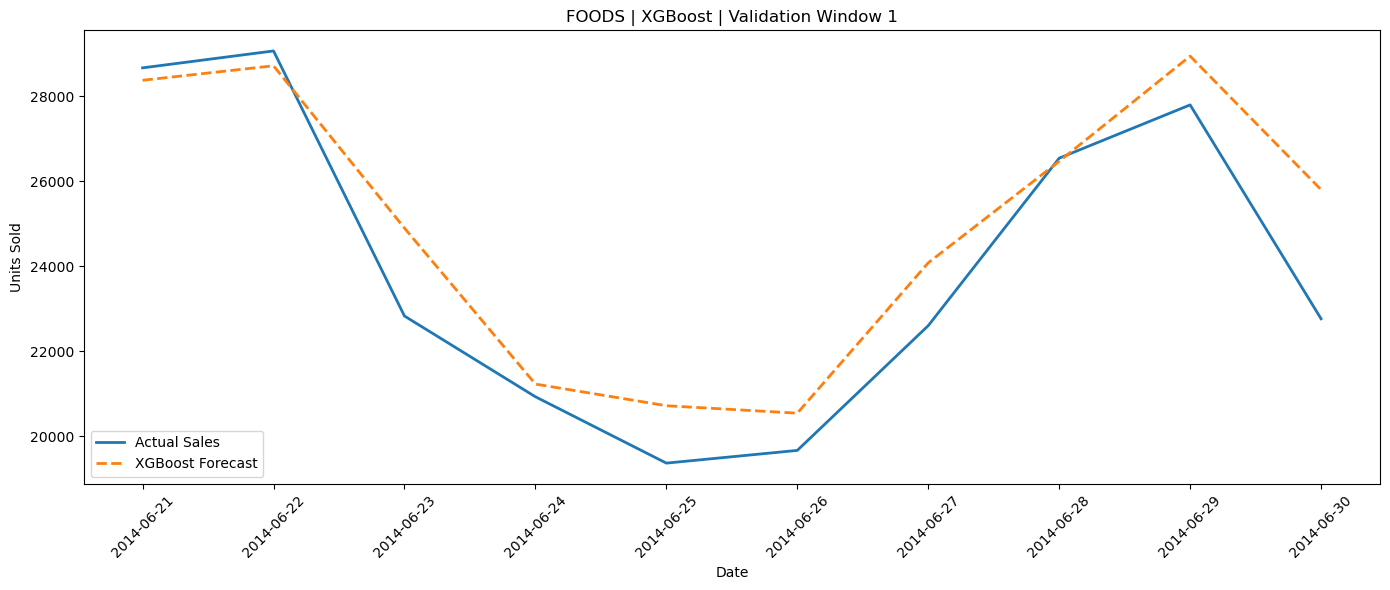

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    validation["ds"],
    validation["y"],
    label="Actual Sales",
    linewidth=2,
)

plt.plot(
    validation["ds"],
    forecasts,
    label="XGBoost Forecast",
    linestyle="--",
    linewidth=2,
)

plt.title(
    f"{category} | XGBoost | "
    f"Validation Window {int(window['window'])}"
)
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
xgboost_settings = [
    {
        "name": "XGBoost Shallow",
        "n_estimators": 300,
        "max_depth": 2,
        "learning_rate": 0.05,
    },
    {
        "name": "XGBoost Base",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.05,
    },
    {
        "name": "XGBoost Deep",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
    },
    {
        "name": "XGBoost Faster",
        "n_estimators": 300,
        "max_depth": 3,
        "learning_rate": 0.10,
    },
]


## Expanding-Window Validation

Each configuration is retrained before every monthly validation window. Forecasts are recursive: each predicted value is added to the history before the next day is forecast.


In [9]:
xgboost_metric_records = []
xgboost_forecast_records = []
xgboost_importance_records = []

for category in development_daily["cat_id"].unique():

    category_data = development_daily[
        development_daily["cat_id"] == category
    ].copy()

    for setting in xgboost_settings:

        for _, window in validation_windows.iterrows():

            train = category_data[
                category_data["ds"] <= window["train_end"]
            ].copy()

            validation = category_data[
                (category_data["ds"] >= window["validation_start"])
                & (category_data["ds"] <= window["validation_end"])
            ].copy()

            train_model_data = model_data[
                (model_data["cat_id"] == category)
                & (model_data["ds"] <= window["train_end"])
            ].dropna(subset=base_features)

            xgb_model = XGBRegressor(
                n_estimators=setting["n_estimators"],
                max_depth=setting["max_depth"],
                learning_rate=setting["learning_rate"],
                random_state=42,
                objective="reg:squarederror",
            )

            xgb_model.fit(
                train_model_data[feature_columns],
                train_model_data["y"],
            )

            history = train["y"].astype(float).tolist()
            forecasts = []

            for forecast_date in validation["ds"]:

                forecast_features = pd.DataFrame(
                    {
                        "lag_1": [history[-1]],
                        "lag_7": [history[-7]],
                        "lag_14": [history[-14]],
                        "lag_28": [history[-28]],
                        "rolling_mean_7": [
                            sum(history[-7:]) / 7
                        ],
                        "rolling_mean_28": [
                            sum(history[-28:]) / 28
                        ],
                        "time_index": [len(history)],
                        "is_christmas": [
                            int(
                                forecast_date.month == 12
                                and forecast_date.day == 25
                            )
                        ],
                        "day_of_week": [
                            forecast_date.dayofweek
                        ],
                        "month": [forecast_date.month],
                    }
                )

                forecast_features = pd.get_dummies(
                    forecast_features,
                    columns=["day_of_week", "month"],
                    dtype=int,
                )

                forecast_features = forecast_features.reindex(
                    columns=feature_columns,
                    fill_value=0,
                )

                prediction = xgb_model.predict(
                    forecast_features
                )[0]

                prediction = max(0, prediction)

                forecasts.append(prediction)
                history.append(prediction)

            metrics = (
                models_metrics.calculate_validation_metrics(
                    actual=validation["y"],
                    forecast=forecasts,
                )
            )

            xgboost_metric_records.append(
                {
                    "cat_id": category,
                    "window": int(window["window"]),
                    "Model": setting["name"],
                    "MAE": metrics["MAE"],
                    "RMSE": metrics["RMSE"],
                    "WAPE (%)": metrics["WAPE (%)"],
                }
            )

            for date, actual_value, forecast_value in zip(
                validation["ds"],
                validation["y"],
                forecasts,
            ):
                xgboost_forecast_records.append(
                    {
                        "cat_id": category,
                        "window": int(window["window"]),
                        "ds": date,
                        "Model": setting["name"],
                        "actual": actual_value,
                        "forecast": forecast_value,
                    }
                )

            for feature, importance in zip(
                feature_columns,
                xgb_model.feature_importances_,
            ):
                xgboost_importance_records.append(
                    {
                        "cat_id": category,
                        "Model": setting["name"],
                        "feature": feature,
                        "importance": importance,
                    }
                )


In [10]:
xgboost_metrics = pd.DataFrame(
    xgboost_metric_records
)

xgboost_forecasts = pd.DataFrame(
    xgboost_forecast_records
)

xgboost_importance = pd.DataFrame(
    xgboost_importance_records
)

xgboost_metrics.groupby(
    ["cat_id", "Model"],
    observed=True,
)["window"].nunique()


cat_id     Model          
FOODS      XGBoost Base       13
           XGBoost Deep       13
           XGBoost Faster     13
           XGBoost Shallow    13
HOBBIES    XGBoost Base       13
           XGBoost Deep       13
           XGBoost Faster     13
           XGBoost Shallow    13
HOUSEHOLD  XGBoost Base       13
           XGBoost Deep       13
           XGBoost Faster     13
           XGBoost Shallow    13
Name: window, dtype: int64

In [11]:
xgboost_summary = (
    xgboost_metrics
    .groupby(
        ["cat_id", "Model"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_MAE=("MAE", "mean"),
        Mean_RMSE=("RMSE", "mean"),
        Mean_WAPE=("WAPE (%)", "mean"),
        Std_WAPE=("WAPE (%)", "std"),
        Best_WAPE=("WAPE (%)", "min"),
        Worst_WAPE=("WAPE (%)", "max"),
    )
    .round(2)
)

xgboost_summary


,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,XGBoost Base,1720.76,2326.11,7.08,1.71,4.57,10.61
1,FOODS,XGBoost Deep,1698.08,2304.71,7.00,1.55,4.92,10.22
2,FOODS,XGBoost Faster,1698.63,2323.12,6.99,1.91,4.16,10.33
3,FOODS,XGBoost Shallow,1703.93,2251.69,7.02,1.54,4.56,10.44
4,HOBBIES,XGBoost Base,259.66,334.73,7.58,2.91,3.65,13.99
5,HOBBIES,XGBoost Deep,253.18,329.04,7.37,2.56,3.92,11.68
6,HOBBIES,XGBoost Faster,267.17,341.24,7.79,3.07,3.73,14.09
7,HOBBIES,XGBoost Shallow,242.48,308.90,7.10,2.10,4.25,11.09
8,HOUSEHOLD,XGBoost Base,618.23,813.00,7.32,2.35,3.07,11.97
9,HOUSEHOLD,XGBoost Deep,638.65,833.22,7.59,1.93,4.93,11.84


In [12]:
best_xgboost_models = (
    xgboost_summary
    .sort_values(
        ["cat_id", "Mean_WAPE", "Std_WAPE"]
    )
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

best_xgboost_models


,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,XGBoost Faster,1698.63,2323.12,6.99,1.91,4.16,10.33
1,HOBBIES,XGBoost Shallow,242.48,308.90,7.10,2.10,4.25,11.09
2,HOUSEHOLD,XGBoost Shallow,588.32,792.51,6.99,2.33,3.00,12.59


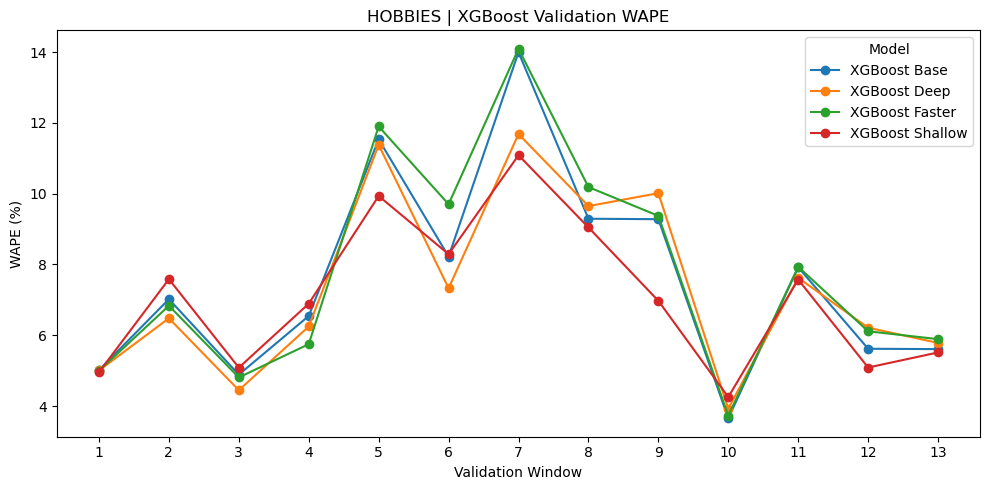

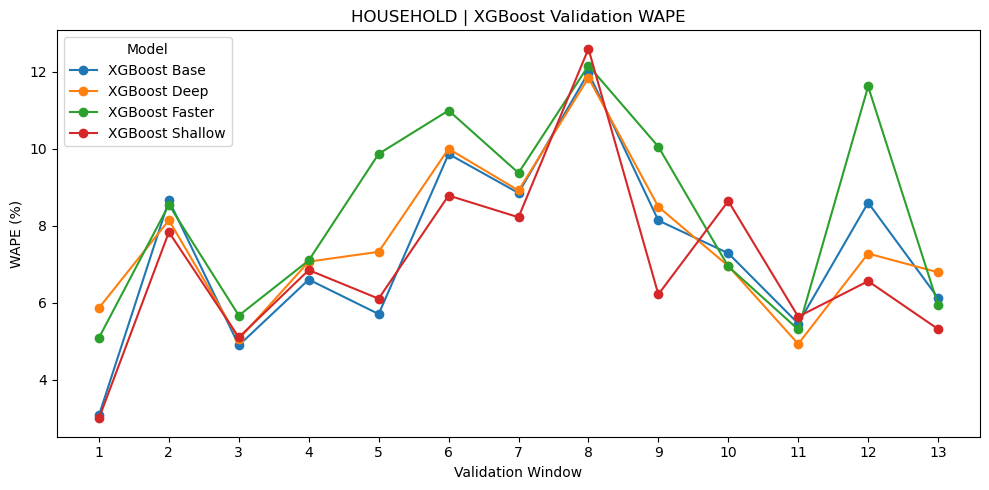

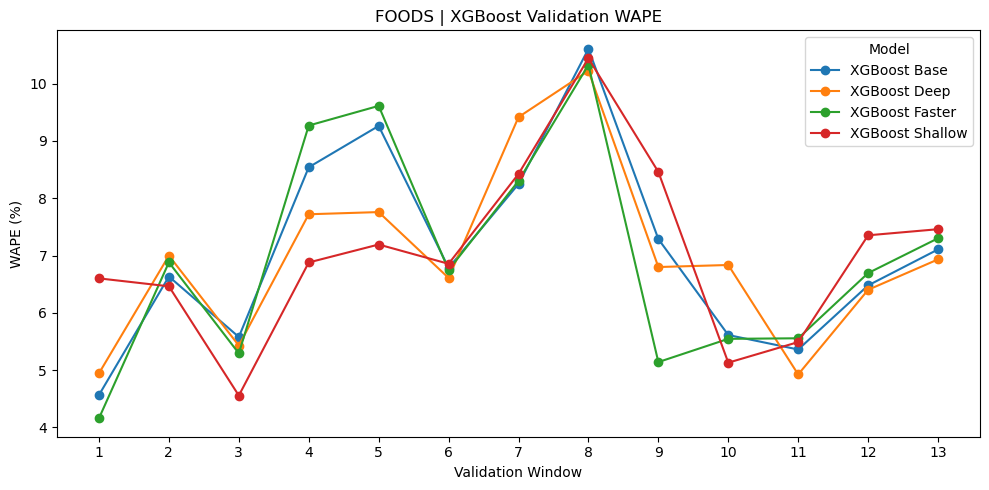

In [13]:
for category in xgboost_metrics["cat_id"].unique():

    plot_data = xgboost_metrics[
        xgboost_metrics["cat_id"] == category
    ]

    comparison = plot_data.pivot(
        index="window",
        columns="Model",
        values="WAPE (%)",
    )

    comparison.plot(
        marker="o",
        figsize=(10, 5),
        title=f"{category} | XGBoost Validation WAPE",
    )

    plt.xlabel("Validation Window")
    plt.ylabel("WAPE (%)")
    plt.xticks(comparison.index)
    plt.tight_layout()
    plt.show()


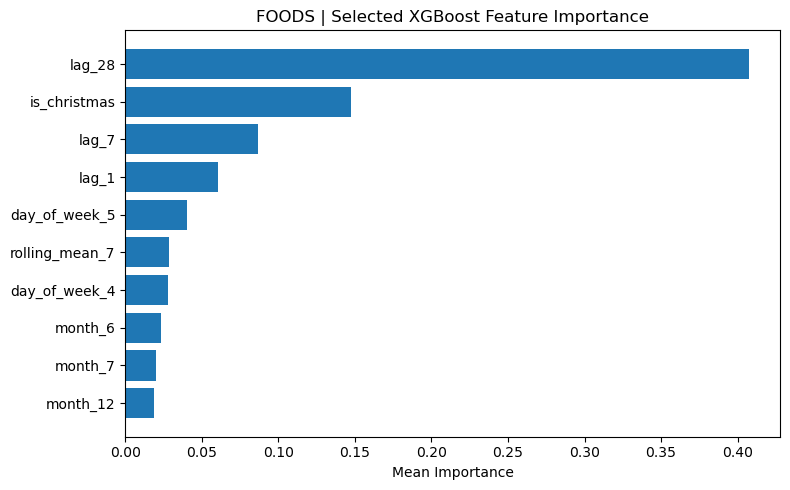

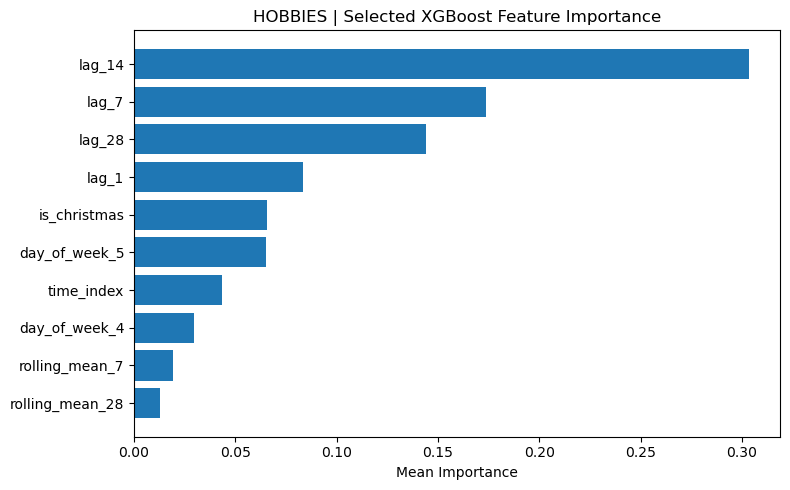

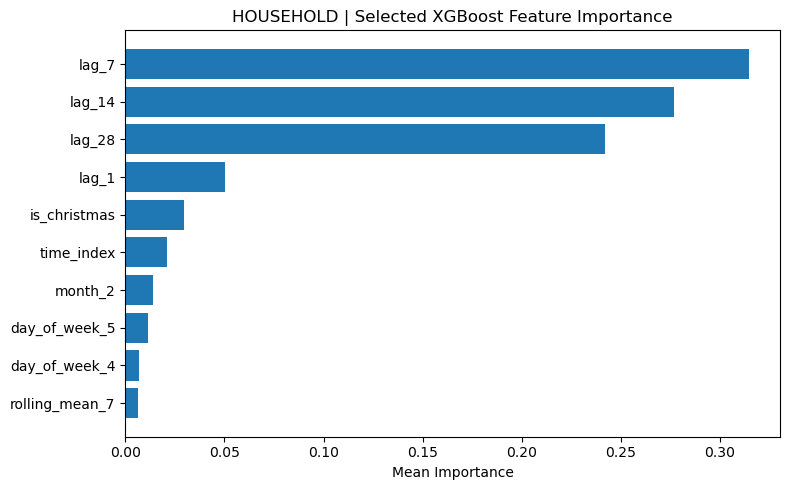

In [14]:
selected_xgboost_importance = (
    xgboost_importance
    .merge(
        best_xgboost_models[
            ["cat_id", "Model"]
        ],
        on=["cat_id", "Model"],
        how="inner",
    )
    .groupby(
        ["cat_id", "feature"],
        observed=True,
        as_index=False,
    )
    .agg(
        Mean_Importance=("importance", "mean")
    )
)

for category in selected_xgboost_importance["cat_id"].unique():

    plot_data = selected_xgboost_importance[
        selected_xgboost_importance["cat_id"] == category
    ].sort_values(
        "Mean_Importance"
    ).tail(10)

    plt.figure(figsize=(8, 5))

    plt.barh(
        plot_data["feature"],
        plot_data["Mean_Importance"],
    )

    plt.title(
        f"{category} | Selected XGBoost Feature Importance"
    )
    plt.xlabel("Mean Importance")
    plt.tight_layout()
    plt.show()


In [15]:
baseline_summary = pd.read_parquet(
    "data/processed/rolling_28d_validation_summary.parquet"
)

linear_summary = pd.read_parquet(
    "data/processed/linear_regression_validation_summary.parquet"
)

prophet_summary = pd.read_parquet(
    "data/processed/prophet_validation_summary.parquet"
)

all_model_validation_summary = pd.concat(
    [
        baseline_summary,
        linear_summary,
        prophet_summary,
        xgboost_summary,
    ],
    ignore_index=True,
).sort_values(
    ["cat_id", "Mean_WAPE", "Std_WAPE"]
).reset_index(drop=True)

all_model_validation_summary


,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,XGBoost Faster,1698.63,2323.12,6.99,1.91,4.16,10.33
1,FOODS,XGBoost Deep,1698.08,2304.71,7.00,1.55,4.92,10.22
2,FOODS,XGBoost Shallow,1703.93,2251.69,7.02,1.54,4.56,10.44
3,FOODS,XGBoost Base,1720.76,2326.11,7.08,1.71,4.57,10.61
4,FOODS,Linear Regression (Reduced),1730.43,2187.47,7.08,1.91,4.35,11.76
5,FOODS,Linear Regression (Full),1798.67,2288.85,7.42,1.94,4.81,12.10
6,FOODS,Prophet Additive,2226.81,2679.09,9.15,2.53,5.61,15.61
7,FOODS,Prophet Flexible,2241.65,2691.15,9.21,2.59,5.92,16.12
8,FOODS,Prophet Multiplicative,2259.74,2699.81,9.29,2.92,5.54,17.27
9,FOODS,Prophet Conservative,2276.33,2750.98,9.36,2.44,5.52,15.43


In [16]:
current_best_models = (
    all_model_validation_summary
    .groupby(
        "cat_id",
        observed=True,
    )
    .first()
    .reset_index()
)

current_best_models


,cat_id,Model,Mean_MAE,Mean_RMSE,Mean_WAPE,Std_WAPE,Best_WAPE,Worst_WAPE
0,FOODS,XGBoost Faster,1698.63,2323.12,6.99,1.91,4.16,10.33
1,HOBBIES,Linear Regression (Full),223.04,290.39,6.50,1.48,4.73,9.14
2,HOUSEHOLD,Prophet Flexible,581.16,765.08,6.88,1.99,3.31,10.72


In [17]:
xgboost_setting_table = pd.DataFrame(
    xgboost_settings
)

best_xgboost_parameters = (
    best_xgboost_models[["cat_id", "Model"]]
    .merge(
        xgboost_setting_table,
        left_on="Model",
        right_on="name",
    )
    .drop(columns="name")
)

xgboost_metrics.to_parquet(
    "data/processed/xgboost_validation_metrics.parquet",
    index=False,
)

xgboost_forecasts.to_parquet(
    "data/processed/xgboost_validation_forecasts.parquet",
    index=False,
)

xgboost_summary.to_parquet(
    "data/processed/xgboost_validation_summary.parquet",
    index=False,
)

best_xgboost_parameters.to_parquet(
    "data/processed/xgboost_best_parameters.parquet",
    index=False,
)

selected_xgboost_importance.to_parquet(
    "data/processed/xgboost_feature_importance.parquet",
    index=False,
)

all_model_validation_summary.to_parquet(
    "data/processed/all_model_validation_summary.parquet",
    index=False,
)


In [18]:
from pathlib import Path

Path("data/models").mkdir(
    parents=True,
    exist_ok=True,
)

for category in development_daily["cat_id"].unique():

    selected_model_name = best_xgboost_models.loc[
        best_xgboost_models["cat_id"] == category,
        "Model",
    ].iloc[0]

    selected_setting = next(
        setting
        for setting in xgboost_settings
        if setting["name"] == selected_model_name
    )

    category_model_data = model_data[
        model_data["cat_id"] == category
    ].dropna(subset=base_features)

    final_xgboost_model = XGBRegressor(
        n_estimators=selected_setting["n_estimators"],
        max_depth=selected_setting["max_depth"],
        learning_rate=selected_setting["learning_rate"],
        random_state=42,
        objective="reg:squarederror",
    )

    final_xgboost_model.fit(
        category_model_data[feature_columns],
        category_model_data["y"],
    )

    final_xgboost_model.save_model(
        f"data/models/xgboost_pretest_{category}.json"
    )

    print(
        f"{category} | {selected_model_name} | "
        f"trained through "
        f"{category_model_data['ds'].max().date()}"
    )


HOBBIES | XGBoost Shallow | trained through 2015-06-20


HOUSEHOLD | XGBoost Shallow | trained through 2015-06-20


FOODS | XGBoost Faster | trained through 2015-06-20


## Conclusion

This notebook evaluated four XGBoost configurations using the same 13 expanding monthly validation windows as the other forecasting models.

| Category | Best XGBoost setup | Previous leading model | Previous validation WAPE | XGBoost validation WAPE | Improvement vs. previous leader |
|---|---|---|---:|---:|---:|
| FOODS | Faster | Linear Regression (Reduced) | 7.08% | 6.99% | 0.09 percentage points |
| HOBBIES | Shallow | Linear Regression (Full) | 6.50% | 7.10% | -0.60 percentage points |
| HOUSEHOLD | Shallow | Prophet Flexible | 6.88% | 6.99% | -0.11 percentage points |

XGBoost only improved on the previous leading model for `FOODS`, and the gain was narrow: 0.09 WAPE points. Linear Regression remained the leading validated model for `HOBBIES`, and Prophet Flexible remained the leading validated model for `HOUSEHOLD`.

Feature importance was reviewed to show which lag, rolling, calendar, and trend inputs contributed most to each selected XGBoost model. XGBoost can capture non-linear relationships, but it is less directly interpretable than Linear Regression and recursive forecasts can still accumulate error over long horizons. Only four small configurations were tested.

The selected XGBoost configuration for each category was refitted on all training and validation history and saved as a pre-test candidate. Its results were later included in the final test comparison.
